In [15]:
import cv2 
import IPython
import numpy as np
import pandas as pd

# from qdrant_client import QdrantClient 
# from qdrant_client.models import Distance, VectorParams, PointStruct

In [16]:
# CLIENT = QdrantClient(host='192.168.0.131', port=6333)   

In [17]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [18]:
def image_from_video(row):
    cap = cv2.VideoCapture(row['filepath'])
    cap.set(cv2.CAP_PROP_POS_FRAMES, row['frame_num'])
    # frame_num = 0
    # while True:
    #     ret, frame = cap.read()
    #     if not ret or frame is None or frame_num == row['frame_num']:
    #         break 
    #     else:
    #         frame_num += 1

    ret, frame = cap.read()
    h, w = (row['img_height'], row['img_width'])
    cv2.rectangle(frame, (int(row['x1'] * w), int(row['y1'] * h)), 
                         (int(row['x2'] * w), int(row['y2'] * h)), (0, 0, 255), 3)
    show_image(frame)

In [19]:
def parse_vector(vector):
    return np.array([float(x) for x in vector.split('\n')])

In [24]:
# src = '../../data/faces/seinfeld_1989_98904/Seinfeld.S01E01.1080p.WEBRip.x265-RARBG.csv'
src = '../../data/test.csv'
df = pd.read_csv(src, index_col=0)
# df['filepath'] = '/home/amos/programs/CineFace/input.m4a'
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,mouth_right_y,mouth_left_x,mouth_left_y,confidence,face_num,frame_num,img_width,img_height,filepath,encoding
0,0.373,0.136,0.541,0.557,0.416,0.292,0.494,0.276,0.460,0.328,...,0.445,0.498,0.432,0.999,0,24,1280,720,/home/amos/programs/CineFace/data/test_videos/...,-0.117702\n-0.0103914\n0.0748744\n-0.119268\n-...
1,0.401,0.150,0.568,0.582,0.446,0.323,0.524,0.307,0.490,0.390,...,0.485,0.521,0.473,0.999,0,48,1280,720,/home/amos/programs/CineFace/data/test_videos/...,-0.135884\n0.0367669\n0.0872471\n-0.110676\n-0...
2,0.398,0.150,0.562,0.572,0.443,0.315,0.519,0.302,0.485,0.374,...,0.473,0.516,0.462,0.999,0,72,1280,720,/home/amos/programs/CineFace/data/test_videos/...,-0.168184\n0.0310253\n0.107776\n-0.114883\n-0....
3,0.405,0.138,0.572,0.569,0.456,0.306,0.533,0.294,0.504,0.365,...,0.464,0.531,0.454,0.999,0,96,1280,720,/home/amos/programs/CineFace/data/test_videos/...,-0.184398\n0.0640058\n0.113221\n-0.108383\n-0....
4,0.387,0.167,0.554,0.578,0.430,0.323,0.509,0.308,0.474,0.380,...,0.478,0.510,0.465,0.999,0,120,1280,720,/home/amos/programs/CineFace/data/test_videos/...,-0.131724\n0.0398403\n0.104206\n-0.166187\n-0....


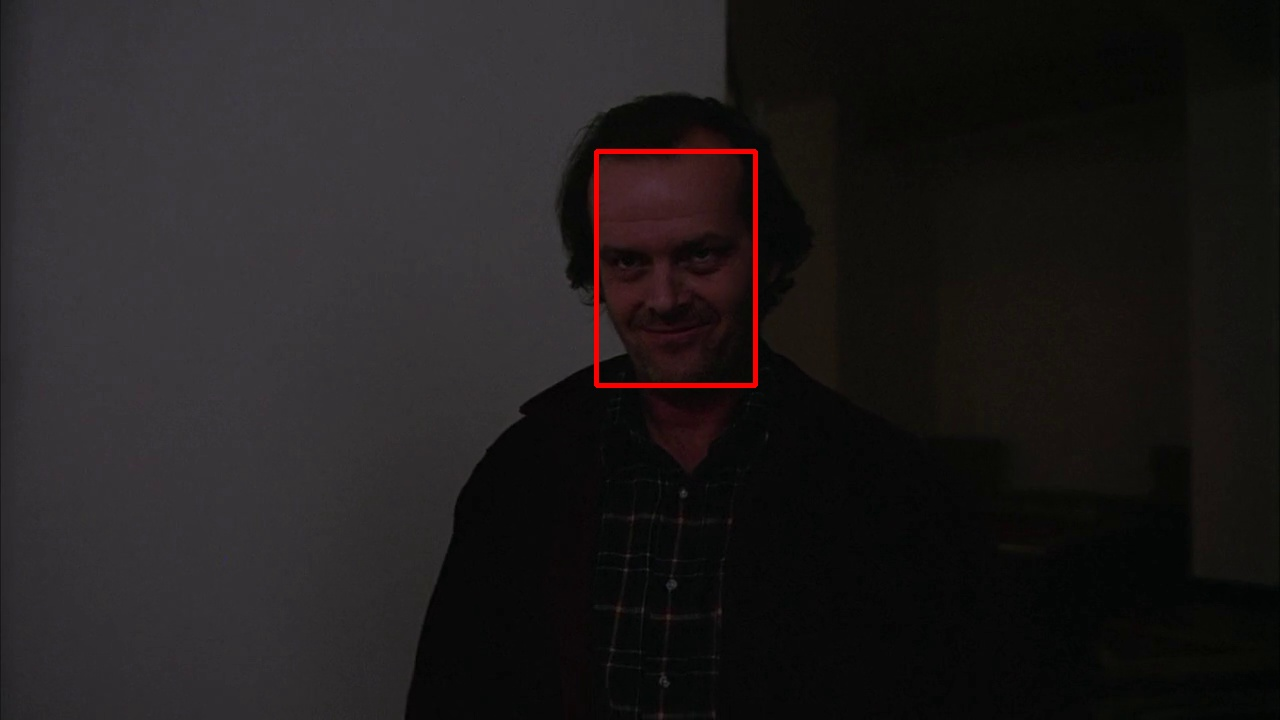

In [26]:
image_from_video(df.iloc[23])

In [7]:
collections = [x.name for x in CLIENT.get_collections().collections]
if 'FacialEmbeddings' not in collections:
    CLIENT.recreate_collection(collection_name='FacialEmbeddings',
                                vectors_config=VectorParams(size=128, distance=Distance.COSINE))

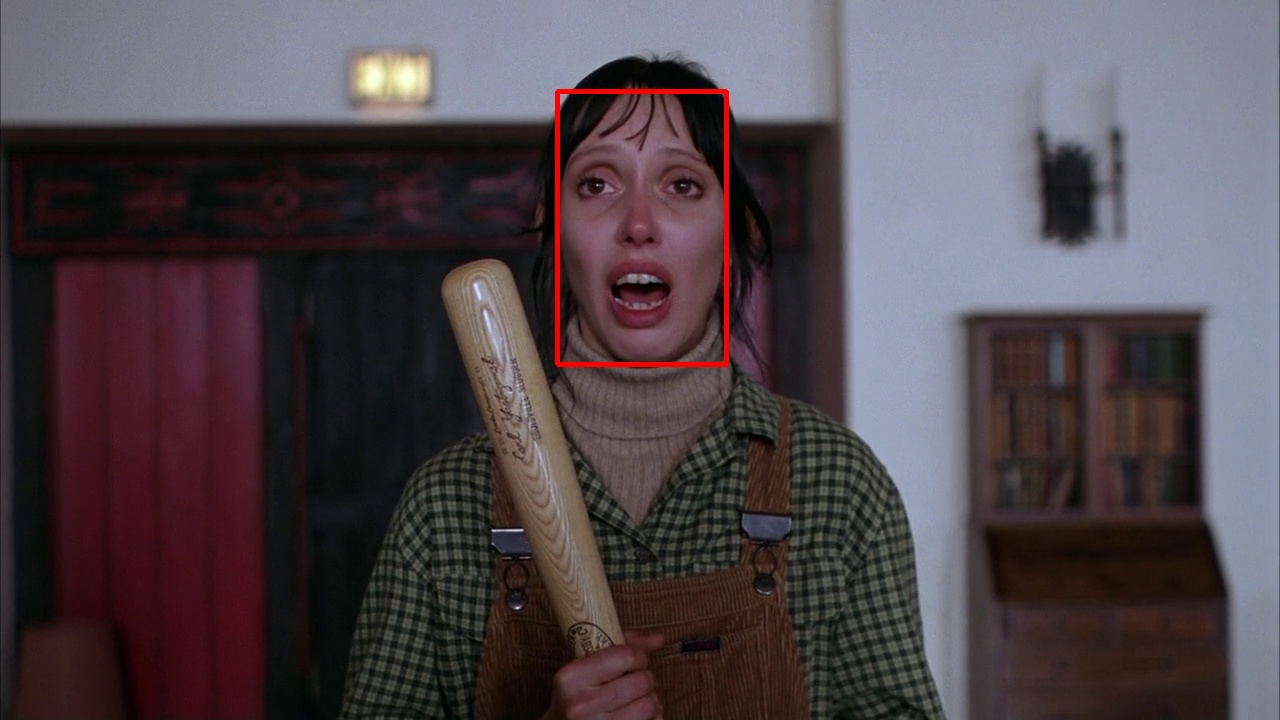